In [1]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

Cloning into 'ceam_task_1'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 148 (delta 4), reused 144 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 2.39 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-12 16:08:01.926881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781280482.210596      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781280482.282257      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781280482.880773      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781280482.880822      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781280482.880828      58 computation_placer.cc:177] computation placer alr

In [3]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [4]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [5]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [6]:
from tensorflow.keras import regularizers

def create_l2_model(l2_value):
    model = keras.Sequential([
        layers.Input(shape=train_images.shape[1:]),

        layers.Conv2D(
            32, (3,3), activation='relu',
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            64, (3,3), activation='relu',
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_value)
        ),

        layers.Dropout(0.5),

        layers.Dense(5, activation='softmax')
    ])

    return model

In [7]:
model_l2_0001 = create_l2_model(0.0001)

model_l2_0001.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2_0001 = model_l2_0001.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

test_loss_l2_0001, test_acc_l2_0001 = model_l2_0001.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"L2=0.0001 Test Accuracy: {test_acc_l2_0001*100:.2f}%")

I0000 00:00:1781280498.923937      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781280498.929973      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1781280501.981137     140 service.cc:152] XLA service 0x78d49c00c1e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781280501.981184     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781280501.981190     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781280502.333555     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-12 16:08:24.485184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 16:08:24.632801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/3 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step - accuracy: 0.3125 - loss: 1.6370

I0000 00:00:1781280507.581401     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-12 16:08:28.855018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 16:08:29.001210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2644 - loss: 4.3488 - val_accuracy: 0.2632 - val_loss: 2.2164
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2759 - loss: 2.1179 - val_accuracy: 0.2105 - val_loss: 1.6563
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2874 - loss: 1.5431 - val_accuracy: 0.3684 - val_loss: 1.3956
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6207 - loss: 1.0667 - val_accuracy: 0.3684 - val_loss: 1.4766
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7356 - loss: 0.8318 - val_accuracy: 0.5263 - val_loss: 1.3230
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8506 - loss: 0.6563 - val_accuracy: 0.5263 - val_loss: 1.2973
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9080 - loss: 0.4353 - val_accuracy: 0.4211 - val_loss: 1.8553
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8621 - loss: 0.4654 - val_accuracy: 0.4737 - val_loss: 1.6545
Epoch 9/50
3

In [8]:
model_l2_001 = create_l2_model(0.001)

model_l2_001.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2_001 = model_l2_001.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

test_loss_l2_001, test_acc_l2_001 = model_l2_001.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"L2=0.001 Test Accuracy: {test_acc_l2_001*100:.2f}%")

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2299 - loss: 11.1051 - val_accuracy: 0.2632 - val_loss: 5.5210
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2989 - loss: 4.6416 - val_accuracy: 0.3684 - val_loss: 2.2401
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3678 - loss: 1.9380 - val_accuracy: 0.4211 - val_loss: 1.7265
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6667 - loss: 1.4183 - val_accuracy: 0.4211 - val_loss: 1.7705
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7816 - loss: 1.0760 - val_accuracy: 0.3158 - val_loss: 1.7559
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8621 - loss: 0.8560 - val_accuracy: 0.3684 - val_loss: 1.9553
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9540 - loss: 0.7335 - val_accuracy: 0.3158 - val_loss: 2.2279
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9425 - loss: 0.7888 - val_accuracy: 0.5263 - val_loss: 2.1600
E

In [9]:
model_l2_01 = create_l2_model(0.01)

model_l2_01.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2_01 = model_l2_01.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

test_loss_l2_01, test_acc_l2_01 = model_l2_01.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"L2=0.01 Test Accuracy: {test_acc_l2_01*100:.2f}%")

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.1264 - loss: 13.4840 - val_accuracy: 0.1579 - val_loss: 8.6781
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.1724 - loss: 8.4137 - val_accuracy: 0.2105 - val_loss: 4.2490
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2644 - loss: 4.1460 - val_accuracy: 0.3684 - val_loss: 4.0448
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5172 - loss: 3.8709 - val_accuracy: 0.3684 - val_loss: 4.0728
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5977 - loss: 3.7395 - val_accuracy: 0.3684 - val_loss: 3.9399
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6782 - loss: 3.5619 - val_accuracy: 0.5263 - val_loss: 3.6925
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8276 - loss: 3.1897 - val_accuracy: 0.5789 - val_loss: 3.5825
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8276 - loss: 2.9852 - val_accuracy: 0.5263 - val_loss: 3.5613
E

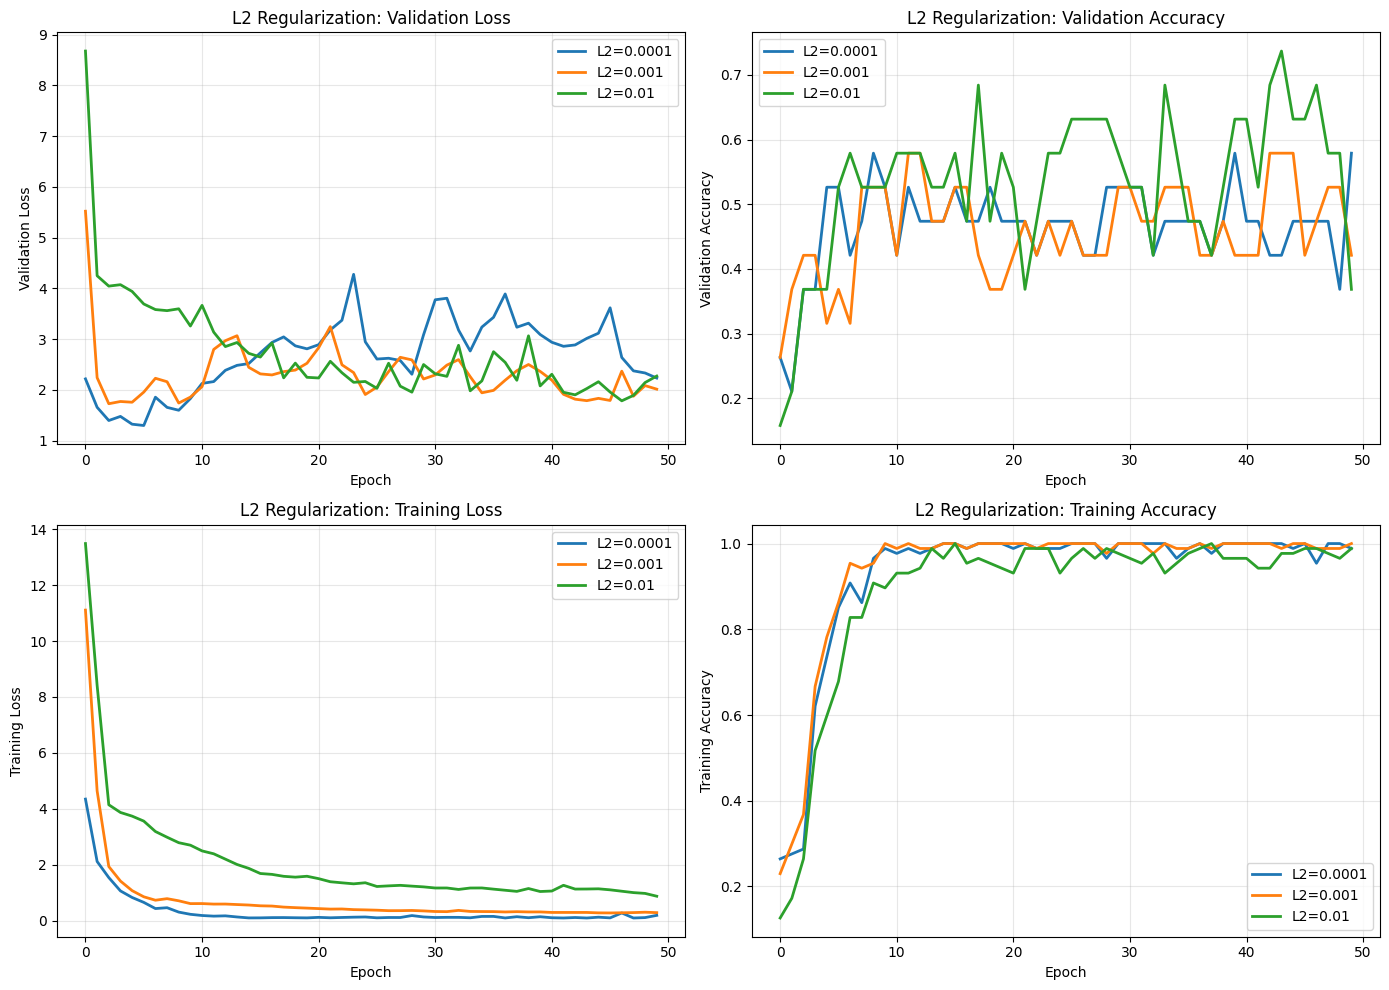

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Loss
axes[0, 0].plot(history_l2_0001.history['val_loss'], label='L2=0.0001', linewidth=2)
axes[0, 0].plot(history_l2_001.history['val_loss'], label='L2=0.001', linewidth=2)
axes[0, 0].plot(history_l2_01.history['val_loss'], label='L2=0.01', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].set_title('L2 Regularization: Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation Accuracy
axes[0, 1].plot(history_l2_0001.history['val_accuracy'], label='L2=0.0001', linewidth=2)
axes[0, 1].plot(history_l2_001.history['val_accuracy'], label='L2=0.001', linewidth=2)
axes[0, 1].plot(history_l2_01.history['val_accuracy'], label='L2=0.01', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('L2 Regularization: Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Training Loss
axes[1, 0].plot(history_l2_0001.history['loss'], label='L2=0.0001', linewidth=2)
axes[1, 0].plot(history_l2_001.history['loss'], label='L2=0.001', linewidth=2)
axes[1, 0].plot(history_l2_01.history['loss'], label='L2=0.01', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('L2 Regularization: Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Training Accuracy
axes[1, 1].plot(history_l2_0001.history['accuracy'], label='L2=0.0001', linewidth=2)
axes[1, 1].plot(history_l2_001.history['accuracy'], label='L2=0.001', linewidth=2)
axes[1, 1].plot(history_l2_01.history['accuracy'], label='L2=0.01', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Training Accuracy')
axes[1, 1].set_title('L2 Regularization: Training Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()